# CYNAR paper 1 -- robustness to measurement noise (merit iv)

Corrupt the observed linear-vortex trajectory componentwise with additive white noise
proportional to the typical fluctuation of each component, $y^i = x^i + \sigma_{x^i}\,R\,\xi^i$ with
$\sigma_{x^i}=\sqrt{\mathrm{Var}(x^i)}$ and $\xi^i$ iid standard Gaussian (independent per component, per time step),
and sweep $R$. CYNAR's traffic fit only uses correlation lags $t\ge t_{i_1}>0$, so it should stay close to
the true $\mathcal{T}$ and $\mathsf D$ even as $R$ grows (the noise only corrupts $C(t{=}0)$, cf.
Di Terlizzi PRL2025 Supplemental Sec. S12); the grid-based inflow rate $\mathcal{G}$, and the
$v^2$-method (which relies entirely on binning/scoring), should both degrade as the noise blurs the score
and drift estimates. This uses a different (additive, white, scaled by each component's standard deviation) noise model than the PRL's
own benchmark and is never compared there against the $v^2$-method, so this comparison is new.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.linear import simulate_linear_diffusion, theory_linear_2N

import common as C

np.set_printoptions(precision=4, suppress=True)

## Model & simulation

Same reference point as `01_linear_vortex.ipynb`'s merit-B (cell-size) study.

In [2]:
dt = 2e-3
Phi = 2.0
T1, T2 = 1.0, 1.0
alph = 0.2

A = np.array([[-alph, -Phi], [alph * Phi, -1.0]])
D = np.array([[T1, 0.0], [0.0, T2]])

T = 500_000
X = simulate_linear_diffusion(T, A, D, dt, oversampling=10, method="euler", seed=12345)

Tr_true, sigma_true, G_true = theory_linear_2N(A, D)
true_values = dict(Tr_true=Tr_true, G_true=G_true, sigma_true=sigma_true)
print(f"alpha={alph}  Tr_true={Tr_true:.4f}  G_true={G_true:.4f}  sigma_true={sigma_true:.4f}")

alpha=0.2  Tr_true=0.9000  G_true=1.2000  sigma_true=4.8000


## Noise sweep

For each relative noise strength $R$ (noise amplitude over signal standard deviation): corrupt $X\to Y$ once via `common.add_relative_noise`, run an
independent $H$-sweep to get the most stable traffic estimate $\mathcal{T}^\star(R)$ and its
by-product $\hat{\mathsf D}(R)$ (`D_from_traffic`), then read the inflow rate $\mathcal{G}(R)$ and
the $v^2$-method's $\sigma_{v^2}(R)$ off a single *fixed* cell size (the $R{=}2$ point from
`01_linear_vortex.ipynb`'s merit-B sweep, $\Delta x=(1.0,0.6)$) -- cell size is a separate axis
(merit ii), not swept here.

In [5]:
H_list = np.linspace(0.05, 0.5, 10)
side0 = (0.5, 0.3)
R_noise_list = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5])
rng = np.random.default_rng(2026)

T1_hat_mean, T1_hat_std = [], []
T2_hat_mean, T2_hat_std = [], []
Tr_star_mean_list, Tr_star_std_list = [], []
sigma_cynar_mean_list, sigma_cynar_std_list = [], []
sigma_v2_mean_list, sigma_v2_std_list = [], []

for Rn in R_noise_list:
    Y = C.add_relative_noise(X, Rn, rng)

    traffic_noise = C.sweep_traffic_vs_H(Y, dt, H_list, N_slice=10)
    tr_star_noise = C.pick_stable_Tr(traffic_noise)
    Tr_star_mean_list.append(tr_star_noise["Tr_star_mean"])
    Tr_star_std_list.append(tr_star_noise["Tr_star_std"])

    D_slices = traffic_noise["D_from_traffic"]
    T1_vals = np.array([Ds[0, 0] for Ds in D_slices])
    T2_vals = np.array([Ds[1, 1] for Ds in D_slices])
    T1_hat_mean.append(T1_vals.mean()); T1_hat_std.append(T1_vals.std(ddof=1))
    T2_hat_mean.append(T2_vals.mean()); T2_hat_std.append(T2_vals.std(ddof=1))

    cellsize_noise = C.sweep_cellsize(Y, dt, D_slices, side0, np.array([2.0]), traffic_noise["slices"])
    sg_mean, sg_std = C.combine_sigma_cynar(
        tr_star_noise["Tr_star_mean"], tr_star_noise["Tr_star_std"],
        cellsize_noise["Gb_mean"][0], cellsize_noise["Gb_std"][0],
    )
    sigma_cynar_mean_list.append(sg_mean); sigma_cynar_std_list.append(sg_std)
    sigma_v2_mean_list.append(cellsize_noise["sigma_v2_mean"][0])
    sigma_v2_std_list.append(cellsize_noise["sigma_v2_std"][0])

    print(f"R={Rn:.2f}  Tr*={tr_star_noise['Tr_star_mean']:.4f}+/-{tr_star_noise['Tr_star_std']:.4f}"
          f"  sigma_CYNAR={sg_mean:.4f}+/-{sg_std:.4f}  sigma_v2={sigma_v2_mean_list[-1]:.4f}")

R=0.00  Tr*=0.9802+/-0.4255  sigma_CYNAR=5.3218+/-1.7060  sigma_v2=7.6492
R=0.05  Tr*=0.9794+/-0.4274  sigma_CYNAR=5.3165+/-1.7157  sigma_v2=10.4225
R=0.10  Tr*=0.9215+/-0.4417  sigma_CYNAR=5.0769+/-1.7749  sigma_v2=23.7210
R=0.15  Tr*=0.9019+/-0.4187  sigma_CYNAR=4.9718+/-1.6801  sigma_v2=57.6804
R=0.20  Tr*=0.9035+/-0.4208  sigma_CYNAR=4.9363+/-1.6886  sigma_v2=123.5701
R=0.30  Tr*=1.0013+/-0.4615  sigma_CYNAR=5.2290+/-1.8508  sigma_v2=381.3197
R=0.40  Tr*=0.9087+/-0.4146  sigma_CYNAR=4.7961+/-1.6629  sigma_v2=957.8259
R=0.50  Tr*=0.9615+/-0.4161  sigma_CYNAR=4.9239+/-1.6675  sigma_v2=1805.1147


## Figure

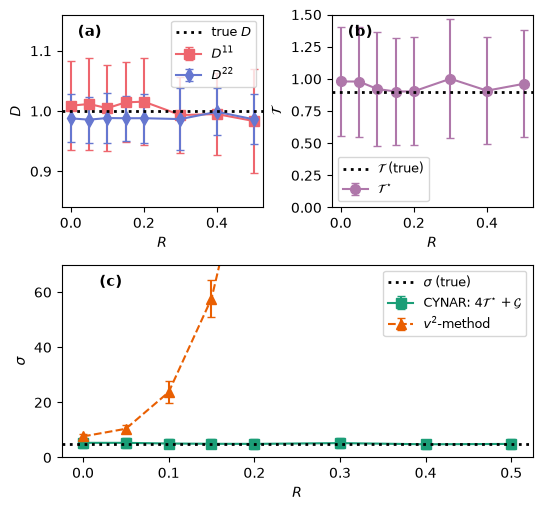

In [12]:
fig, axd = plt.subplot_mosaic([["a", "b"], ["c", "c"]], figsize=(5.4, 5.0), constrained_layout=True)

axd["a"].errorbar(R_noise_list, T1_hat_mean, yerr=T1_hat_std, fmt="s-", capsize=3, markersize=7,
                color="#EE666E", label=r"$D^{11}$")
axd["a"].errorbar(R_noise_list, T2_hat_mean, yerr=T2_hat_std, fmt="d-", capsize=3, markersize=7,
                color="#6677D0", label=r"$D^{22}$")
if T1!=T2:
    axd["a"].axhline(T1, color="black", linestyle=":", lw=2, label=r"true $D^{11}$",zorder=100)
    axd["a"].axhline(T2, color="black", linestyle="--", lw=1.3, label=r"true $D^{22}$",zorder=100)
else:
    axd["a"].axhline(T1, color="black", linestyle=":", lw=2, label=r"true $D$",zorder=100)
axd["a"].set_xlabel("$R$"); axd["a"].set_ylabel(r"$D$")
axd["a"].legend(fontsize=9)
C.add_panel_label(axd["a"], "(a)")

axd["b"].errorbar(R_noise_list, Tr_star_mean_list, yerr=Tr_star_std_list, fmt="o-", capsize=3, markersize=7,
                color=C.COLOR_TRAFFIC, label=r"$\mathcal{T}^\star$")
axd["b"].axhline(Tr_true, **C.TRUE_STYLE, label=r"$\mathcal{T}$ (true)",zorder=100)
axd["b"].set_xlabel("$R$"); axd["b"].set_ylabel(r"$\mathcal{T}$")
axd["b"].legend(fontsize=9)
C.add_panel_label(axd["b"], "(b)")

axd["c"].axhline(sigma_true, **C.TRUE_STYLE, label=r"$\sigma$ (true)",zorder=100)
axd["c"].errorbar(R_noise_list, sigma_cynar_mean_list, yerr=sigma_cynar_std_list, fmt="s-", capsize=3,
                markersize=7, color=C.CYNAR_COLOR, label=r"CYNAR: $4\mathcal{T}^\star+\mathcal{G}$")
axd["c"].errorbar(R_noise_list, sigma_v2_mean_list, yerr=sigma_v2_std_list, fmt="^--", capsize=3,
                markersize=7, color=C.V2_COLOR, label=r"$v^2$-method")
axd["c"].set_xlabel("$R$"); axd["c"].set_ylabel(r"$\sigma$")
axd["c"].legend(fontsize=9)
C.add_panel_label(axd["c"], "(c)")

axd["a"].set_ylim(.84,1.16)
axd["b"].set_ylim(0,1.5)
axd["c"].set_ylim(0,70)

#fig.suptitle("linear vortex: robustness to measurement noise")
fig.savefig(str(C.FIGURES_DIR / "noise_robustness.pdf"), dpi=200, bbox_inches="tight")
plt.show()

C.save_result("noise_robustness", dict(
    R_noise_list=R_noise_list, T1_hat_mean=T1_hat_mean, T1_hat_std=T1_hat_std,
    T2_hat_mean=T2_hat_mean, T2_hat_std=T2_hat_std,
    Tr_star_mean_list=Tr_star_mean_list, Tr_star_std_list=Tr_star_std_list,
    sigma_cynar_mean_list=sigma_cynar_mean_list, sigma_cynar_std_list=sigma_cynar_std_list,
    sigma_v2_mean_list=sigma_v2_mean_list, sigma_v2_std_list=sigma_v2_std_list,
    true_values=true_values, alph=alph, Phi=Phi, T1=T1, T2=T2, side0=side0,
))